# Customer Churn Prediction


##  Objetivo

O objetivo  é analisar o comportamento dos clientes de uma empresa de telecomunicações e identificar padrões associados ao cancelamento dos serviços (churn).

Cada linha representa um cliente e cada coluna contém uma característica relacionada ao cliente, aos serviços contratados ou à sua conta.

A variável Churn indica se o cliente cancelou o serviço no último mês e será utilizada como variável-alvo neste projeto.

## Sobre o dataset

| Variável | Descrição |
|---|---|
| `customerID` | Identificador único do cliente |
| `gender` | Gênero do cliente |
| `SeniorCitizen` | Indicador de cliente idoso |
| `Partner` | Indica se o cliente possui parceiro |
| `Dependents` | Indica se o cliente possui dependentes |
| `tenure` | Tempo de permanência do cliente na empresa em meses|
| `PhoneService` | Indica se o cliente possui serviço telefônico |
| `MultipleLines` | Indica se o cliente possui múltiplas linhas telefônicas |
| `InternetService` | Tipo de serviço de internet contratado |
| `OnlineSecurity` | Indica se o cliente possui serviço de segurança online |
| `OnlineBackup` | Indica se o cliente possui serviço de backup online |
| `DeviceProtection` | Indica se o cliente possui proteção para dispositivos |
| `TechSupport` | Indica se o cliente possui suporte técnico |
| `StreamingTV` | Indica se o cliente possui serviço de streaming de TV |
| `StreamingMovies` | Indica se o cliente possui serviço de streaming de filmes |
| `Contract` | Tipo de contrato do cliente |
| `PaperlessBilling` | Indica se o cliente utiliza cobrança sem papel |
| `PaymentMethod` | Método de pagamento utilizado pelo cliente |
| `MonthlyCharges` | Valor cobrado mensalmente |
| `TotalCharges` | Valor total cobrado do cliente |
| `Churn` | Indica se o cliente deixou a empresa |

## Importação das bibliotecas


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option("display.max_columns", 50)

## Carregando os dados

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

## Visão geral do dataset


In [5]:
print(f"Linhas: {df.shape[0]:,} | Colunas: {df.shape[1]}")
display(df.head())

Linhas: 7,043 | Colunas: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

`TotalCharges` deveria ser numérica, mas aparece como texto (`str`/`object`). Isso indica valores não numéricos escondidos na coluna.

# Verificando a qualidade dos dados

Observando nulos, duplicatas, tipos, valores inválidos e consistência entre colunas.

In [13]:
nulos = df.isna().sum()
print("Colunas com nulos:", nulos[nulos > 0].to_dict() or "nenhuma")
print("Linhas duplicadas:", df.duplicated().sum())
print("customerID duplicado:", df["customerID"].duplicated().sum())

Colunas com nulos: nenhuma
Linhas duplicadas: 0
customerID duplicado: 0


### o `TotalCharges`
O `isna()` não achou nada, mas a coluna é texto. Convertemos com `errors="coerce"` (o que não for número vira `NaN`) para **descobrir** quais linhas são problemáticas.

In [14]:
tc_num = pd.to_numeric(df["TotalCharges"], errors="coerce")
invalidos = df[tc_num.isna()]

print(f"TotalCharges não numérico: {len(invalidos)} linhas")
display(invalidos[["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]])
print("Valores de tenure nessas linhas:", invalidos["tenure"].unique())

TotalCharges não numérico: 11 linhas


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


Valores de tenure nessas linhas: [0]


As 11 linhas têm `tenure = 0`. São clientes recém-chegados que ainda não receberam nenhuma cobrança, e nenhum deles deu churn. Não é dado faltante aleatório: o valor correto é **0**.

## Verificando a consistência entre as colunas

In [15]:
cols_internet = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                 "TechSupport", "StreamingTV", "StreamingMovies"]

# 'No internet service' deve coincidir exatamente com InternetService == 'No'
sem_net_nas_colunas = (df[cols_internet] == "No internet service").all(axis=1).sum()
print("Clientes com 'No internet service' em todas as 6 colunas:", sem_net_nas_colunas)
print("Clientes com InternetService == 'No':", (df["InternetService"] == "No").sum())

# 'No phone service' deve coincidir com PhoneService == 'No'
print("MultipleLines == 'No phone service':", (df["MultipleLines"] == "No phone service").sum())
print("PhoneService == 'No':", (df["PhoneService"] == "No").sum())

# TotalCharges deveria ser ~ tenure * MonthlyCharges
ok = df.assign(tc=tc_num).query("tenure > 0")
razao = ok["tc"] / (ok["tenure"] * ok["MonthlyCharges"])
print(f"\nTotalCharges / (tenure*MonthlyCharges): mediana={razao.median():.3f}, "
      f"min={razao.min():.2f}, max={razao.max():.2f}")

Clientes com 'No internet service' em todas as 6 colunas: 1526
Clientes com InternetService == 'No': 1526
MultipleLines == 'No phone service': 682
PhoneService == 'No': 682

TotalCharges / (tenure*MonthlyCharges): mediana=1.000, min=0.69, max=1.57


**Conclusões da checagem**
- As categorias `No internet service` e `No phone service` são **redundantes**: a informação já está em `InternetService` e `PhoneService`. No pré-processamento podem virar `No`.
- `TotalCharges` é quase `tenure × MonthlyCharges`, portanto é **muito correlacionada** com as outras duas

# Limpando a base

In [16]:
df_analise = df.copy()

# TotalCharges: texto -> número; clientes sem cobrança ainda (tenure == 0) recebem 0
df_analise["TotalCharges"] = pd.to_numeric(df_analise["TotalCharges"], errors="coerce")
df_analise.loc[df_analise["tenure"] == 0, "TotalCharges"] = 0.0

# SeniorCitizen vem como 0/1; padronizamos para Yes/No como as demais binárias
df_analise["SeniorCitizen"] = df_analise["SeniorCitizen"].map({0: "No", 1: "Yes"})

# Alvo numérico (0/1) para calcular taxas e correlações com facilidade
df_analise["churn_bin"] = (df_analise['Churn'] == "Yes").astype(int)

assert df_analise["TotalCharges"].isna().sum() == 0, "Ainda há nulos em TotalCharges"
print("Limpeza concluída. Nulos restantes:", int(df_analise.isna().sum().sum()))

Limpeza concluída. Nulos restantes: 0


In [17]:
# Listas de colunas reutilizadas em todo o notebook
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
cat_cols = [c for c in df_analise.columns
            if c not in num_cols + ["customerID", 'Churn', "churn_bin"]]

print(f"{len(num_cols)} numéricas | {len(cat_cols)} categóricas")
print("Categóricas:", cat_cols)

3 numéricas | 16 categóricas
Categóricas: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [18]:
df_analise.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,churn_bin
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## Observando a variavel Churn

,clientes,%
Churn,,
No,5174,73.5
Yes,1869,26.5


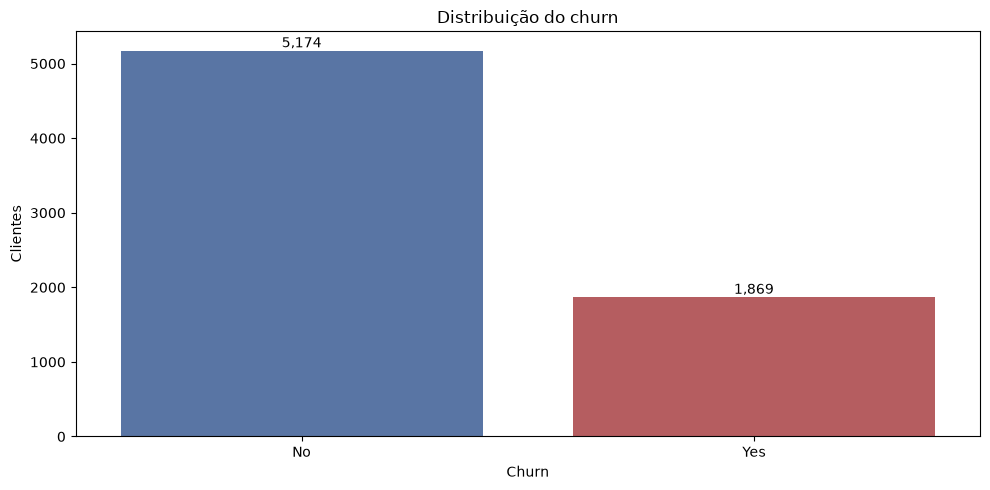

Taxa de churn global: 26.5%  (baseline: prever 'ninguém sai' acerta 73.5%)


In [19]:
COR_CHURN = {"No": "#4C72B0", "Yes": "#C44E52"}   # azul = ficou | vermelho = saiu
contagem = df_analise['Churn'].value_counts()
pct = df_analise['Churn'].value_counts(normalize=True) * 100
display(pd.DataFrame({"clientes": contagem, "%": pct.round(1)}))

taxa_global = df_analise["churn_bin"].mean()

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df_analise, x='Churn', hue='Churn', order=["No", "Yes"],
              palette=COR_CHURN, legend=False, ax=ax)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
ax.set_title("Distribuição do churn")
ax.set_ylabel("Clientes")
plt.tight_layout()
plt.show()

print(f"Taxa de churn global: {taxa_global:.1%}  (baseline: prever 'ninguém sai' acerta {1 - taxa_global:.1%})")

## Análise univariada

### Númericas

,count,mean,std,min,25%,50%,75%,max,assimetria
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,0.239540
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,-0.220524
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,0.963235


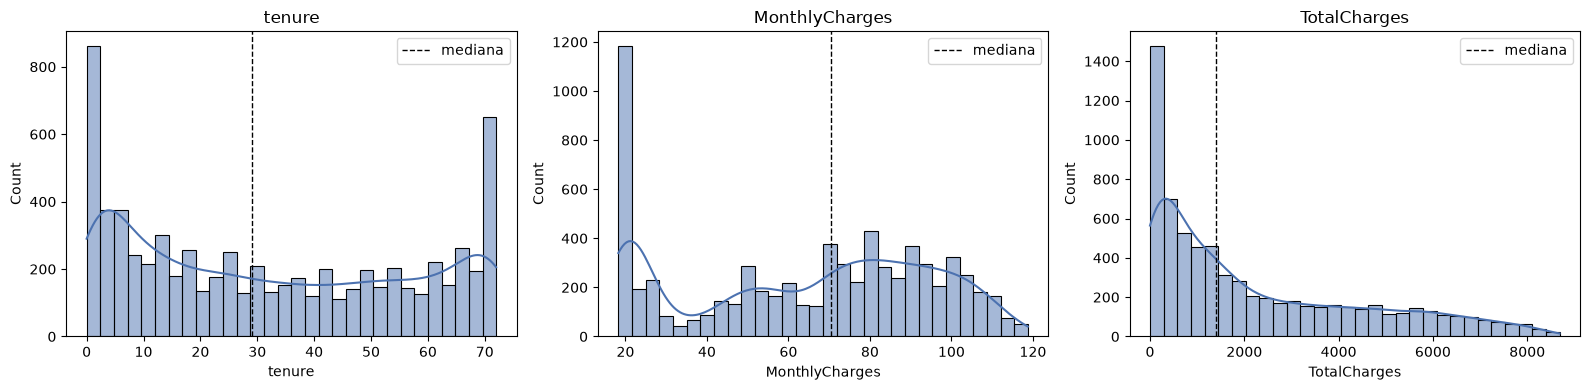

In [20]:
display(df_analise[num_cols].describe().T.assign(assimetria=df_analise[num_cols].skew()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    sns.histplot(df_analise[col], bins=30, kde=True, ax=ax, color="#4C72B0")
    ax.axvline(df_analise[col].median(), color="k", ls="--", lw=1, label="mediana")
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

- `tenure`: distribuição **bimodal** (muitos clientes novos e muitos com ~70 meses).
- `MonthlyCharges`: pico em ~20 (clientes só com telefone) e massa entre 70 e 100 (internet com serviços extras).
- `TotalCharges`: assimetria positiva, consequência de acumular tenure × mensalidade.

## Categóricas

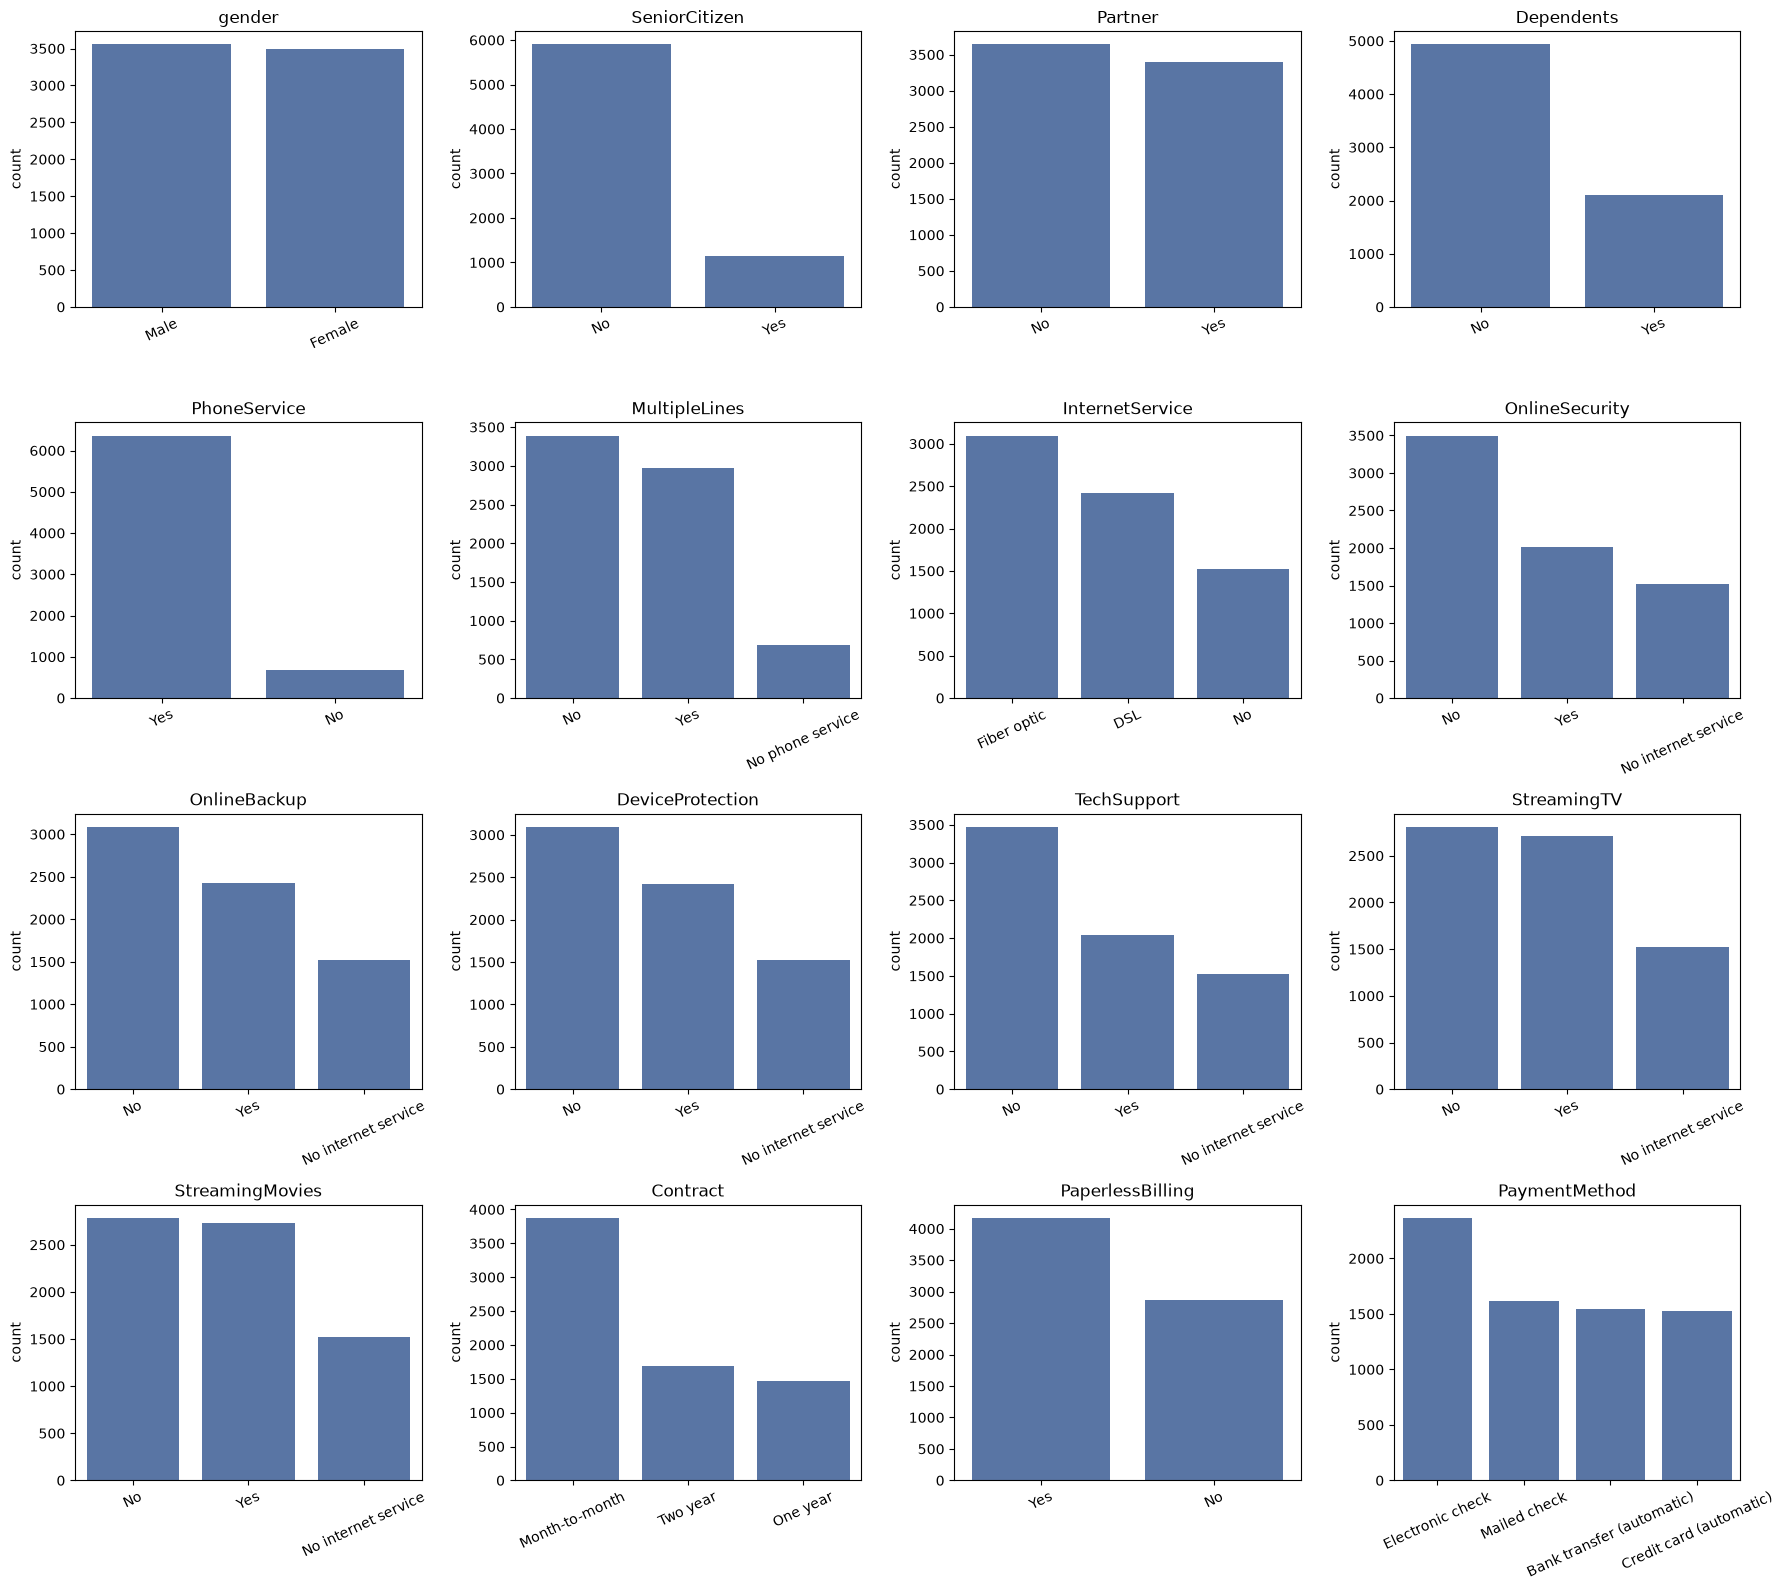

In [23]:


n_cols = 4
n_rows = int(np.ceil(len(cat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
for ax, col in zip(axes.ravel(), cat_cols):
    ordem = df_analise[col].value_counts().index
    sns.countplot(data=df_analise, x=col, order=ordem, ax=ax, color="#4C72B0")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

Nenhuma categoria é extremamente rara, então não há necessidade de agrupar níveis. Chamam atenção: contrato mensal é o mais comum (~55%) e fibra óptica é o serviço de internet mais contratado.

# Análise Bivarada

## Variaveis Numéricas x Churn

Churn                      No     Yes
tenure         mean      37.6    18.0
               median    38.0    10.0
MonthlyCharges mean      61.3    74.4
               median    64.4    79.6
TotalCharges   mean    2549.9  1531.8
               median  1679.5   703.6

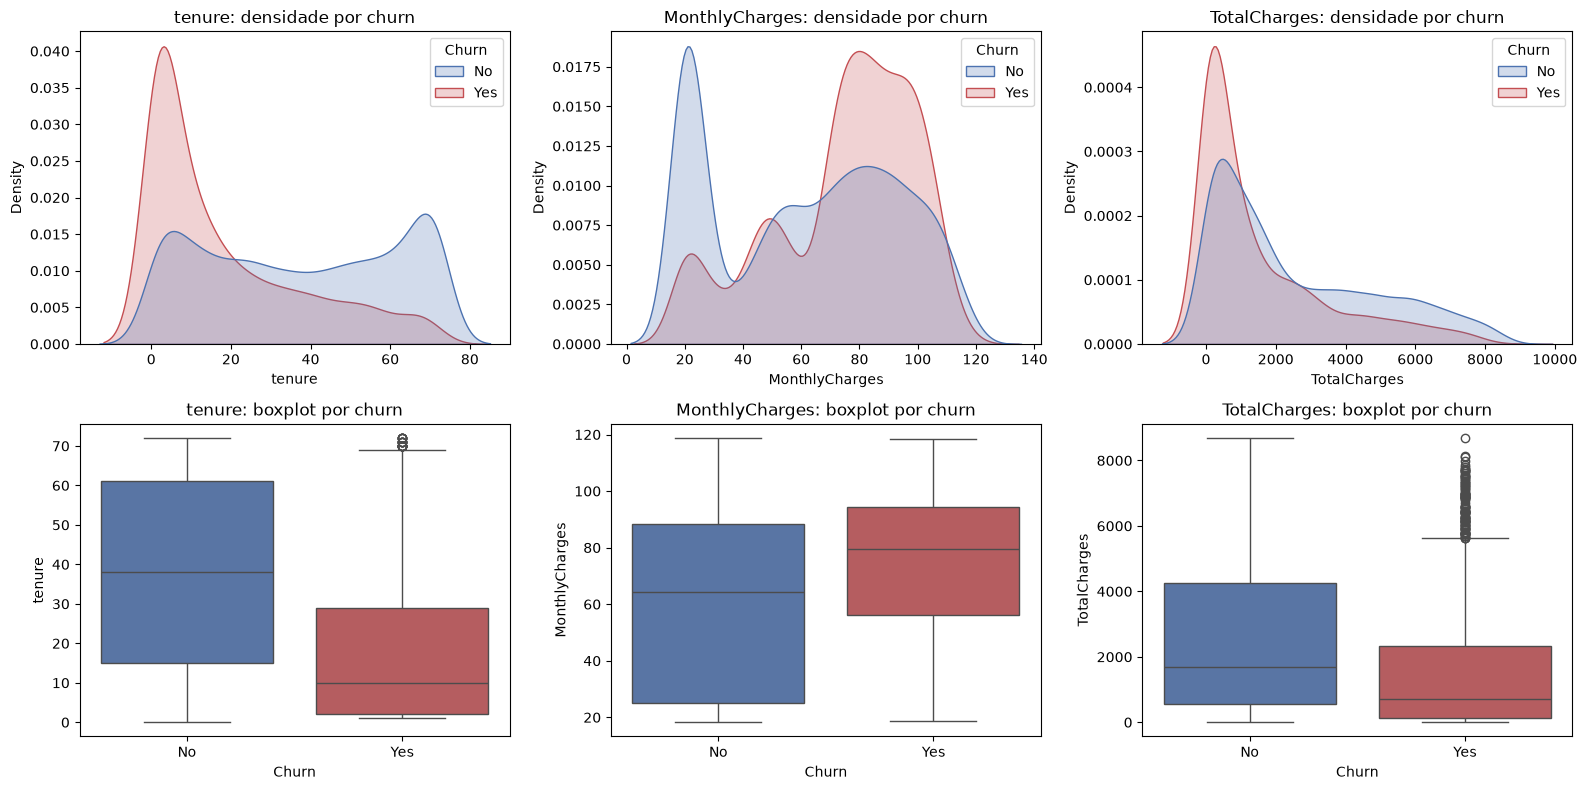

In [24]:
display(df_analise.groupby('Churn')[num_cols].agg(["mean", "median"]).round(1).T)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for i, col in enumerate(num_cols):
    sns.kdeplot(data=df_analise, x=col, hue='Churn', common_norm=False, fill=True,
                palette=COR_CHURN, ax=axes[0, i])
    axes[0, i].set_title(f"{col}: densidade por churn")
    sns.boxplot(data=df_analise, x='Churn', y=col, hue='Churn', order=["No", "Yes"],
                palette=COR_CHURN, legend=False, ax=axes[1, i])
    axes[1, i].set_title(f"{col}: boxplot por churn")
plt.tight_layout()
plt.show()

- `tenure`: quem sai tem mediana de ~10 meses contra ~38 de quem fica. É a variável numérica mais discriminante.
- `MonthlyCharges`: quem sai paga mais em média (~74 vs ~61).
- `TotalCharges`: menor entre quem sai, mas isso é *reflexo* do tenure baixo, não um efeito próprio.

Variáveis numéricas contínuas escondem padrões não lineares. Discretizamos em faixas para ver a taxa de churn em cada uma.

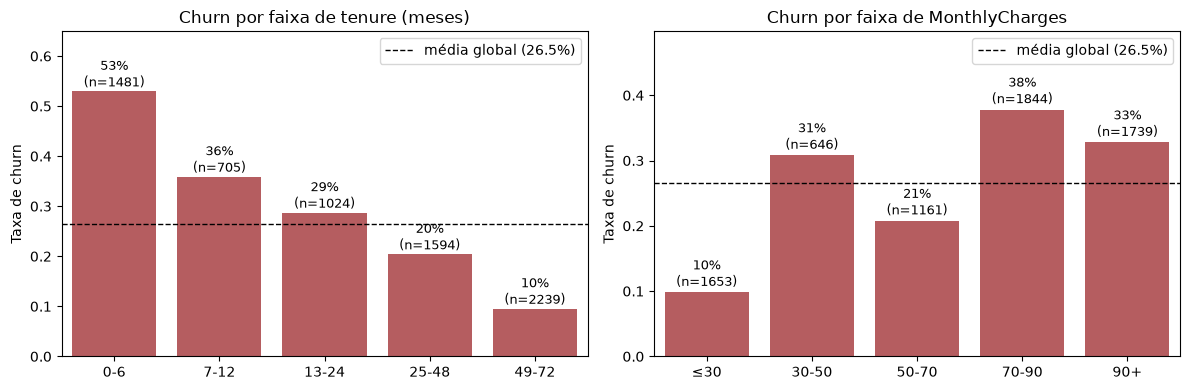

In [25]:
def taxa_por_faixa(serie, bins, labels=None):
    faixas = pd.cut(serie, bins=bins, labels=labels, include_lowest=True)
    return df_analise.groupby(faixas, observed=True)["churn_bin"].agg(taxa="mean", n="count")

tenure_faixas = taxa_por_faixa(df_analise["tenure"], [0, 6, 12, 24, 48, 72],
                               ["0-6", "7-12", "13-24", "25-48", "49-72"])
mensal_faixas = taxa_por_faixa(df_analise["MonthlyCharges"], [0, 30, 50, 70, 90, 120],
                               ["≤30", "30-50", "50-70", "70-90", "90+"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, tab, titulo in zip(axes, [tenure_faixas, mensal_faixas],
                           ["Churn por faixa de tenure (meses)", "Churn por faixa de MonthlyCharges"]):
    sns.barplot(x=tab.index.astype(str), y=tab["taxa"], color="#C44E52", ax=ax)
    ax.axhline(taxa_global, color="k", ls="--", lw=1, label=f"média global ({taxa_global:.1%})")
    for i, (t, n) in enumerate(zip(tab["taxa"], tab["n"])):
        ax.text(i, t + 0.01, f"{t:.0%}\n(n={n})", ha="center", fontsize=9)
    ax.set_title(titulo)
    ax.set_ylabel("Taxa de churn")
    ax.set_xlabel("")
    ax.set_ylim(0, tab["taxa"].max() + 0.12)
    ax.legend()
plt.tight_layout()
plt.show()

O risco é altíssimo nos primeiros 6 meses (~53%) e cai de forma monotônica até ~10% depois de 4 anos. Para `MonthlyCharges` a relação **não é linear**: a faixa ≤30 é muito segura (grande parte são clientes sem internet), e o churn dispara acima de 70.

## Categoricas x Churn

Para cada categoria calculamos a taxa de churn . A linha tracejada é a média global: barras acima dela são grupos de risco.

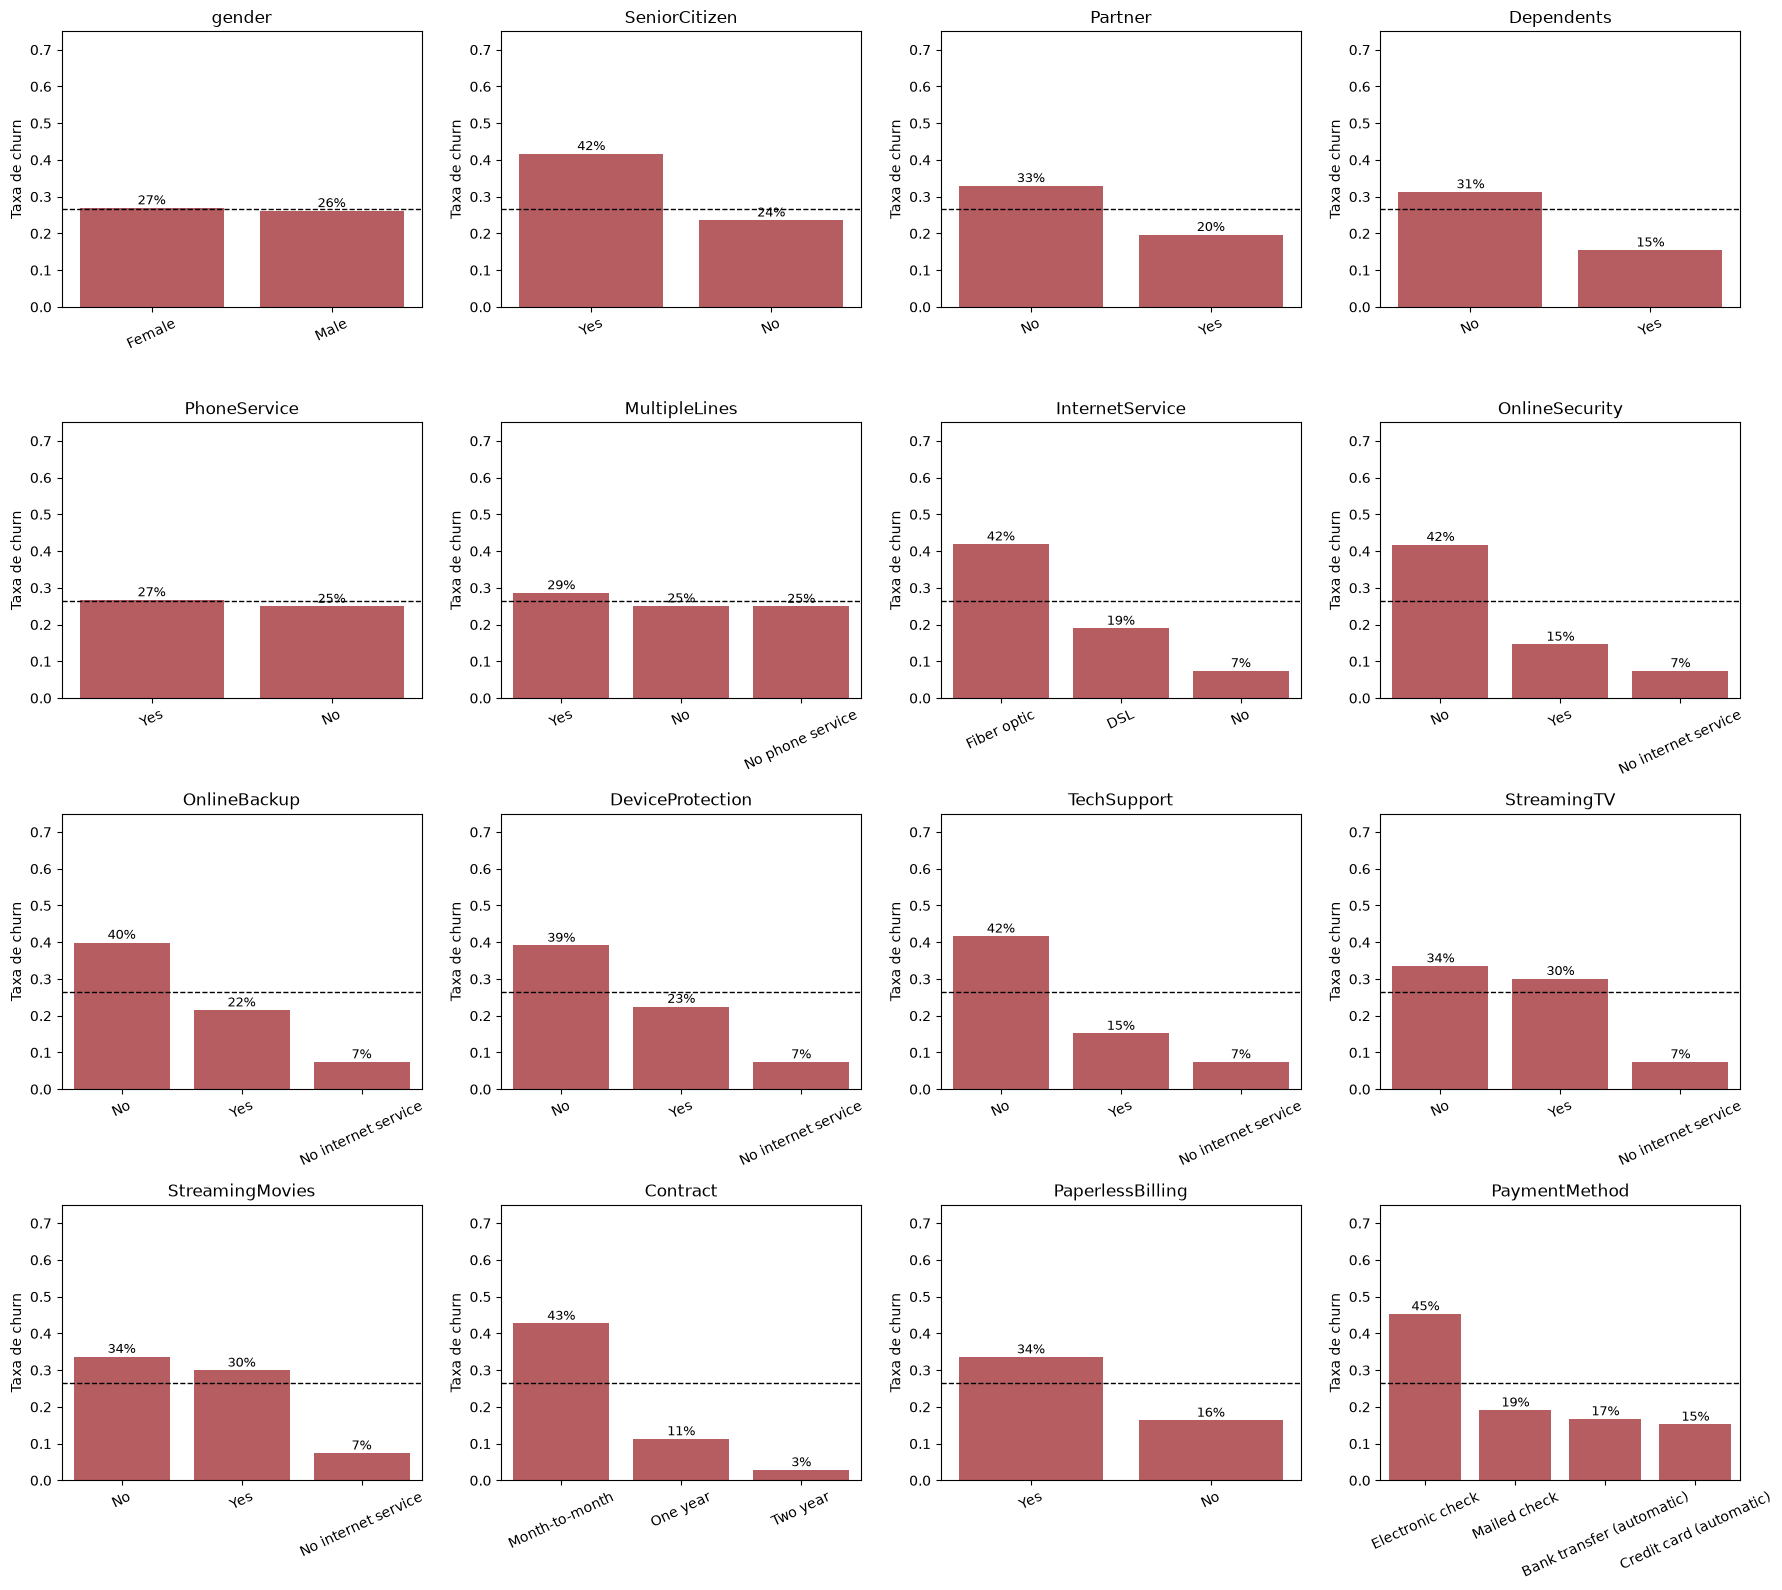

In [18]:
def taxa_churn(col):
    return (df_analise.groupby(col)["churn_bin"].agg(taxa="mean", n="count")
              .reset_index().sort_values("taxa", ascending=False))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
for ax, col in zip(axes.ravel(), cat_cols):
    tab = taxa_churn(col)
    sns.barplot(data=tab, x=col, y="taxa", color="#C44E52", ax=ax)
    ax.axhline(taxa_global, color="k", ls="--", lw=1)
    for i, t in enumerate(tab["taxa"]):
        ax.text(i, t + 0.01, f"{t:.0%}", ha="center", fontsize=9)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, 0.75)
    ax.tick_params(axis="x", rotation=25)
for ax in axes.ravel()[len(cat_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()

## Ranking de importância (associação com o churn)
Os gráficos mostram *como* cada variável se relaciona com o churn; agora medimos *quanto*.
- **Categóricas:** V de Cramér (0 = sem associação, 1 = associação perfeita), com correção de viés.
- **Numéricas:** correlação com o alvo binário.

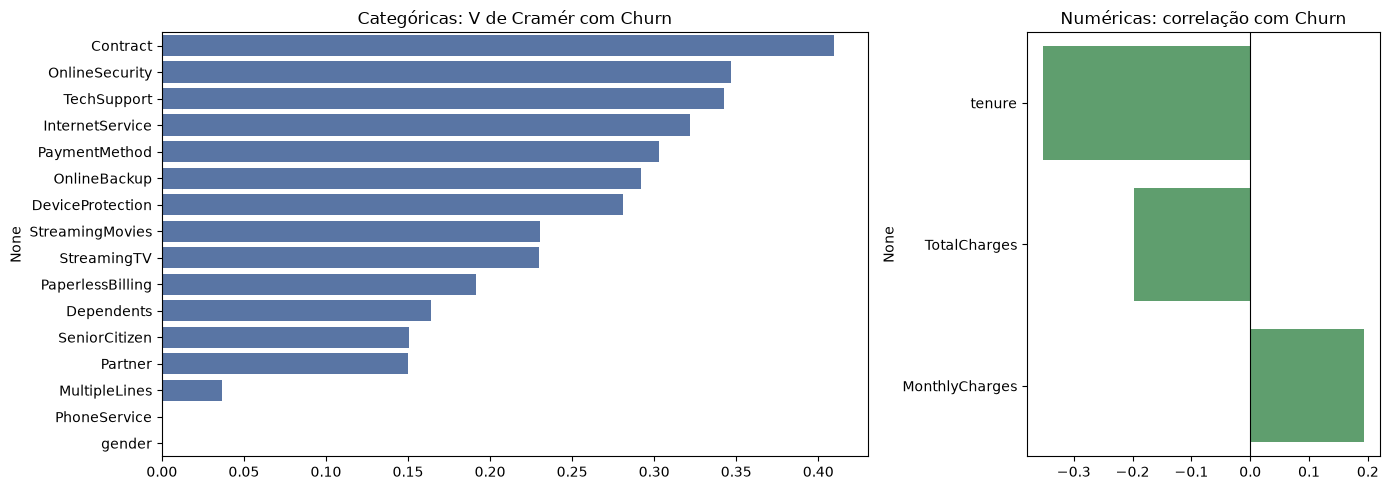

,V de Cramér
Contract,0.410
OnlineSecurity,0.347
TechSupport,0.343
InternetService,0.322
PaymentMethod,0.303
OnlineBackup,0.292
DeviceProtection,0.281
StreamingMovies,0.230
StreamingTV,0.230
PaperlessBilling,0.191


In [26]:
def cramers_v(x, y):
    tab = pd.crosstab(x, y)
    chi2 = chi2_contingency(tab, correction=False)[0]
    n = tab.values.sum()
    r, k = tab.shape
    phi2 = max(0, chi2 / n - ((k - 1) * (r - 1)) / (n - 1))
    rc = r - ((r - 1) ** 2) / (n - 1)
    kc = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2 / min(kc - 1, rc - 1))

assoc_cat = (pd.Series({c: cramers_v(df_analise[c], df_analise['Churn']) for c in cat_cols})
               .sort_values(ascending=False))
assoc_num = df_analise[num_cols].corrwith(df_analise["churn_bin"]).sort_values(key=abs, ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})
sns.barplot(x=assoc_cat.values, y=assoc_cat.index, color="#4C72B0", ax=axes[0])
axes[0].set_title("Categóricas: V de Cramér com Churn")
sns.barplot(x=assoc_num.values, y=assoc_num.index, color="#55A868", ax=axes[1])
axes[1].axvline(0, color="k", lw=0.8)
axes[1].set_title("Numéricas: correlação com Churn")
plt.tight_layout()
plt.show()

display(assoc_cat.round(3).to_frame("V de Cramér"))

# Analise multivariada



## Correlação entre numéricas

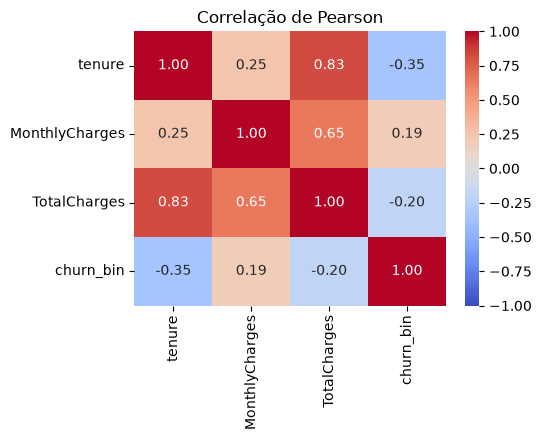

In [19]:
corr = df_analise[num_cols + ["churn_bin"]].corr()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlação de Pearson")
plt.tight_layout()
plt.show()

`TotalCharges` tem correlação alta com `tenure` (~0,83) e com `MonthlyCharges` (~0,65): é em grande parte a **multiplicação** das duas.

## Verificando a concentração do Risco

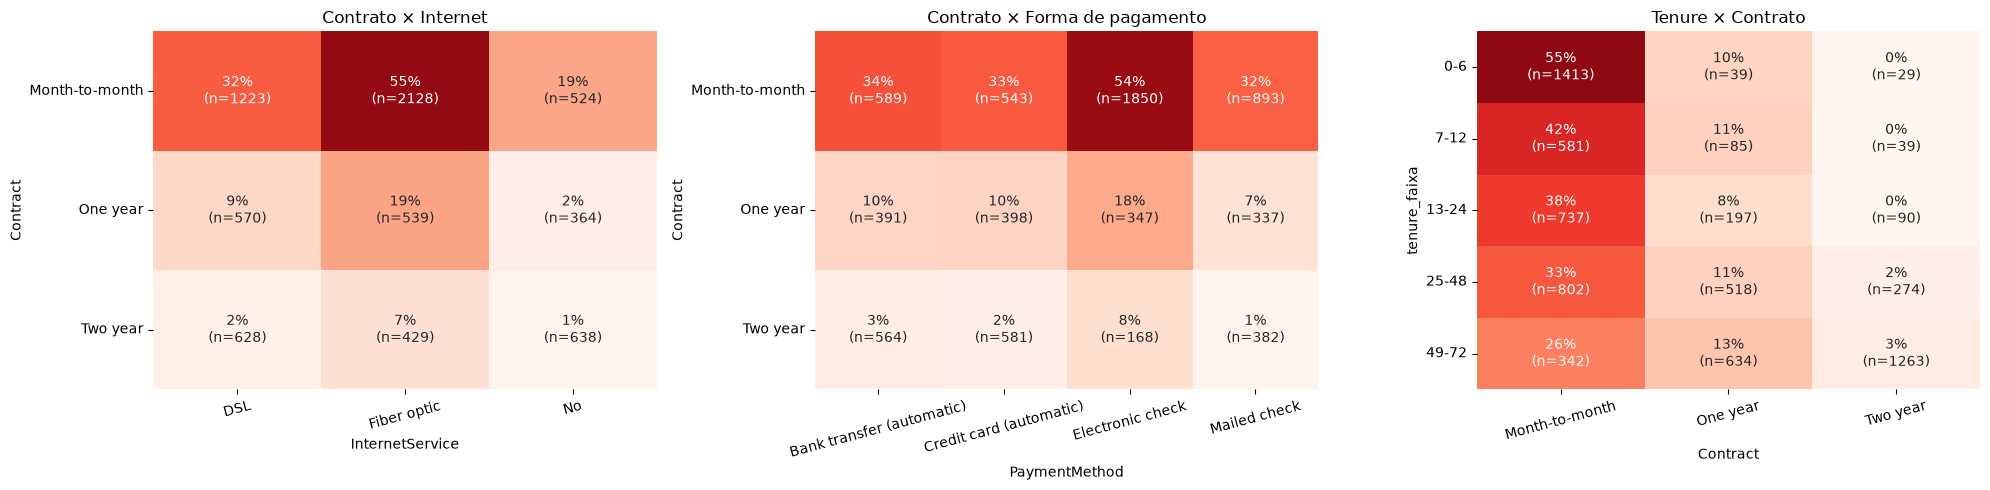

In [27]:
ORDEM_CONTRATO = ["Month-to-month", "One year", "Two year"]

def heatmap_churn(linhas, colunas, ax, titulo):
    tab = df_analise.pivot_table(index=linhas, columns=colunas, values="churn_bin", aggfunc="mean")
    n = df_analise.pivot_table(index=linhas, columns=colunas, values="churn_bin", aggfunc="count")
    if linhas == "Contract":                      # ordem lógica: do mais curto ao mais longo
        tab, n = tab.loc[ORDEM_CONTRATO], n.loc[ORDEM_CONTRATO]
    if colunas == "Contract":
        tab, n = tab[ORDEM_CONTRATO], n[ORDEM_CONTRATO]
    anot = tab.map(lambda v: f"{v:.0%}") + "\n(n=" + n.astype(int).astype(str) + ")"
    sns.heatmap(tab, annot=anot, fmt="", cmap="Reds", vmin=0, vmax=0.6, cbar=False, ax=ax)
    ax.set_title(titulo)
    ax.tick_params(axis="y", rotation=0)
    ax.tick_params(axis="x", rotation=15)

df_analise["tenure_faixa"] = pd.cut(df_analise["tenure"], [0, 6, 12, 24, 48, 72],
                            labels=["0-6", "7-12", "13-24", "25-48", "49-72"], include_lowest=True)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
heatmap_churn("Contract", "InternetService", axes[0], "Contrato × Internet")
heatmap_churn("Contract", "PaymentMethod", axes[1], "Contrato × Forma de pagamento")
heatmap_churn("tenure_faixa", "Contract", axes[2], "Tenure × Contrato")
plt.tight_layout()
plt.show()

- **Contrato mensal + fibra óptica** é o segmento mais crítico (~55% de churn em ~2.100 clientes).
- O efeito ruim do **cheque eletrônico** aparece sobretudo nos contratos mensais.
- Os contratos de 1 e 2 anos protegem em todos os cruzamentos, inclusive nos primeiros meses (mas há poucos clientes com contrato longo e tenure baixo, por isso as células têm `n` pequeno; cuidado ao interpretar).

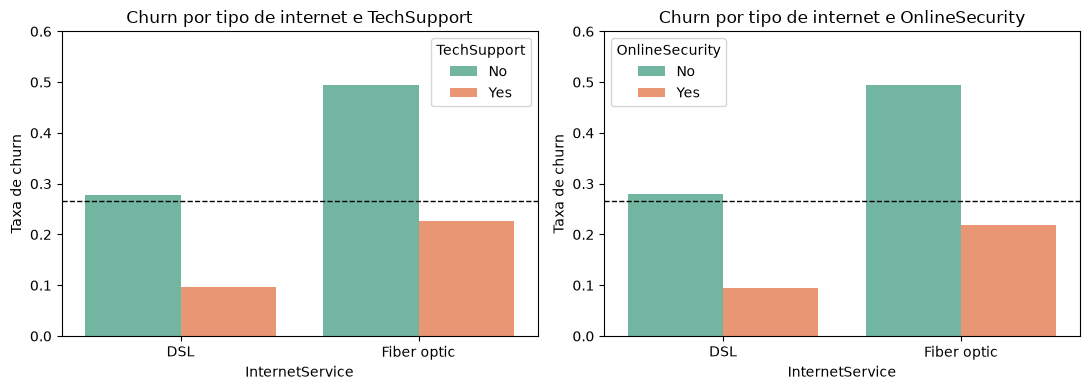

In [28]:
# Serviços de suporte/segurança dentro de cada tipo de internet
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col in zip(axes, ["TechSupport", "OnlineSecurity"]):
    sub = df_analise[df_analise["InternetService"] != "No"]
    tab = sub.groupby(["InternetService", col])["churn_bin"].mean().reset_index()
    sns.barplot(data=tab, x="InternetService", y="churn_bin", hue=col, ax=ax, palette="Set2")
    ax.axhline(taxa_global, color="k", ls="--", lw=1)
    ax.set_title(f"Churn por tipo de internet e {col}")
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, 0.6)
plt.tight_layout()
plt.show()

 dentro de **cada** tipo de internet, quem tem suporte técnico/segurança online sai bem menos. Ou seja, o efeito não é só "fibra vs DSL". Continua sendo correlação, porém (engajamento pode ser o fator oculto).

In [30]:
servicos = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"]
protecao = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
streaming = ["StreamingTV", "StreamingMovies"]

df_analise["n_servicos"] = (df_analise[servicos] == "Yes").sum(axis=1)
df_analise["n_protecao"] = (df_analise[protecao] == "Yes").sum(axis=1)
df_analise["n_streaming"] = (df_analise[streaming] == "Yes").sum(axis=1)

tab_geral = df_analise.groupby("n_servicos")["churn_bin"].agg(taxa="mean", n="count")
tab_internet = (df_analise[df_analise["InternetService"] != "No"]
                .groupby("n_servicos")["churn_bin"].agg(taxa="mean", n="count"))

display(pd.concat({"todos os clientes": tab_geral, "só quem tem internet": tab_internet}, axis=1))

todos os clientes       só quem tem internet      
                        taxa     n                 taxa     n
n_servicos                                                   
0                   0.214060  2219             0.522367   693
1                   0.457557   966             0.457557   966
2                   0.358180  1033             0.358180  1033
3                   0.273703  1118             0.273703  1118
4                   0.223005   852             0.223005   852
5                   0.124343   571             0.124343   571
6                   0.052817   284             0.052817   284

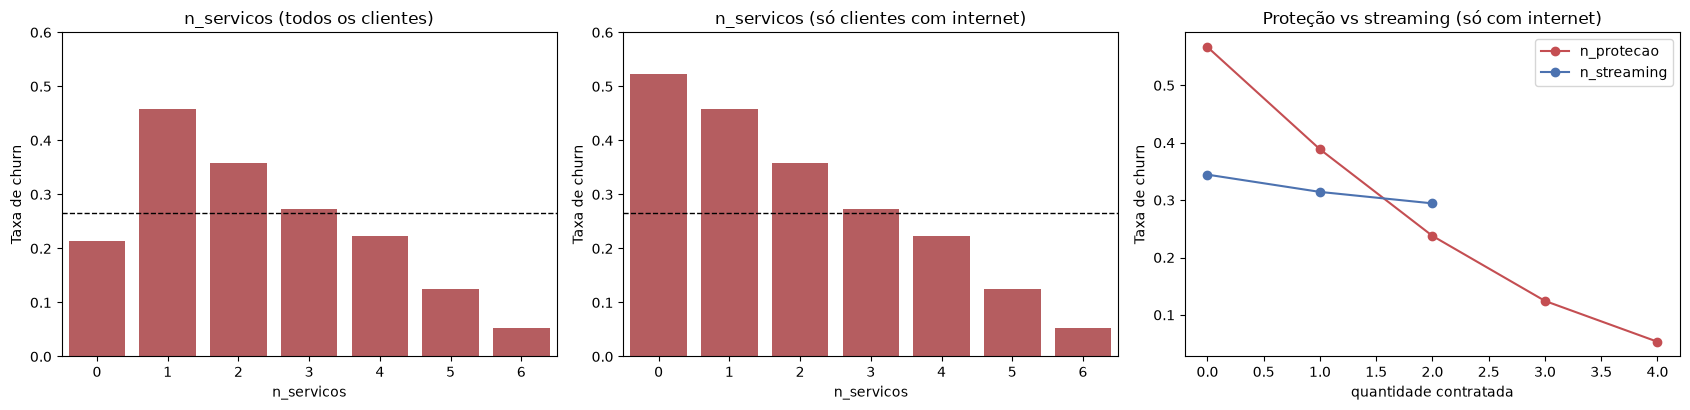

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

for ax, tab, titulo in zip(axes[:2], [tab_geral, tab_internet],
                           ["n_servicos (todos os clientes)", "n_servicos (só clientes com internet)"]):
    sns.barplot(x=tab.index, y=tab["taxa"], color="#C44E52", ax=ax)
    ax.axhline(taxa_global, color="k", ls="--", lw=1)
    ax.set_title(titulo)
    ax.set_ylabel("Taxa de churn")
    ax.set_ylim(0, 0.6)

sub = df_analise[df_analise["InternetService"] != "No"]
for col, cor in [("n_protecao", "#C44E52"), ("n_streaming", "#4C72B0")]:
    t = sub.groupby(col)["churn_bin"].mean()
    axes[2].plot(t.index, t.values, marker="o", label=col, color=cor)
axes[2].set_title("Proteção vs streaming (só com internet)")
axes[2].set_xlabel("quantidade contratada")
axes[2].set_ylabel("Taxa de churn")
axes[2].legend()
plt.tight_layout()
plt.show()

## Conclusões sobre a EDA

A taxa de churn é de aproximadamente 26,5%, indicando desbalanceamento moderado da variável target.

Contrato mensal apresentou a maior taxa de churn, com aproximadamente 43%, enquanto contratos de 1 e 2 anos apresentaram taxas consideravelmente menores.

O churn é mais elevado entre clientes com menor tempo de permanência, especialmente nos primeiros meses.

Clientes com Fiber optic apresentaram maior taxa de churn em comparação com clientes com DSL ou sem serviço de internet.
A combinação de contrato mensal + fibra óptica apresentou uma taxa de churn particularmente elevada.

A ausência de serviços como OnlineSecurity e TechSupport esteve associada a maiores taxas de churn.

Electronic check apresentou uma das maiores taxas de churn entre os métodos de pagamento.

gender e PhoneService apresentaram pouca diferença entre suas categorias em relação ao churn.

TotalCharges estava armazenada como texto e precisou ser convertida para uma variável numérica.

Algumas variáveis apresentam relações entre si, portanto os padrões observados individualmente não devem ser interpretados como relações causais.
Considerações para o preprocessing

A EDA indicou a necessidade de tratar tipos de dados, variáveis categóricas e possíveis redundâncias antes da modelagem. Também será necessário considerar o desbalanceamento da variável target durante a avaliação dos modelos.